In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df = df.drop("id", axis=1)

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.0,223.0,268.0,603.0
thalch,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2
ca,309.0,0.676375,0.935653,0.0,0.0,0.0,1.0,3.0
num,920.0,0.995652,1.142693,0.0,0.0,1.0,2.0,4.0


In [9]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


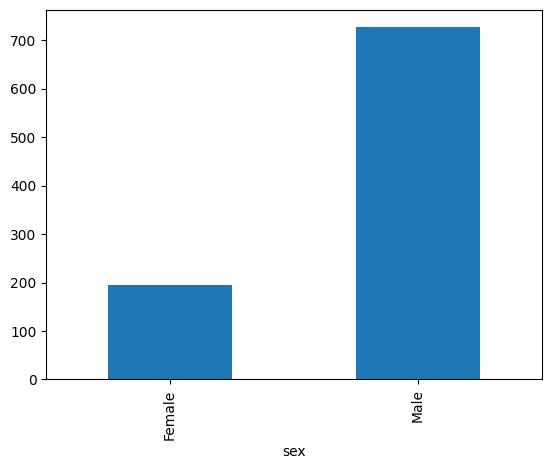

In [15]:
df.groupby('sex')['dataset'].size().plot(kind='bar');

In [14]:
df['dataset'].value_counts()

,count
dataset,
Cleveland,304
Hungary,293
VA Long Beach,200
Switzerland,123


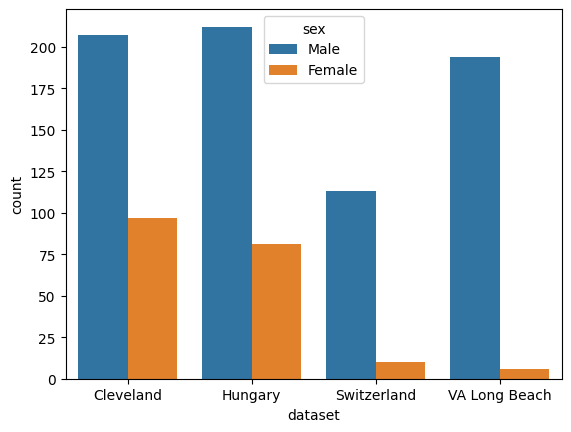

In [18]:
sns.countplot(x='dataset', hue='sex', data=df);

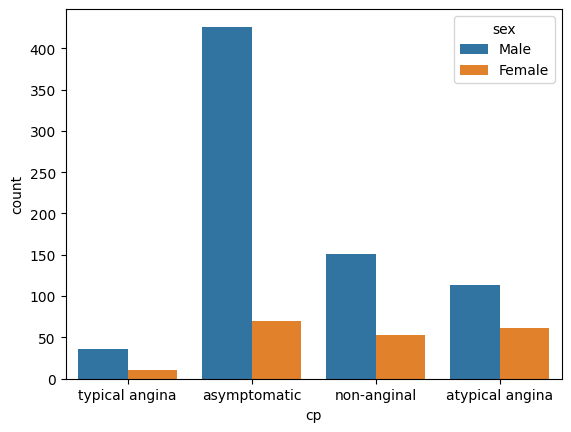

In [29]:
sns.countplot(x='cp', hue='sex', data=df);

In [32]:
df.groupby('cp')['age'].mean();

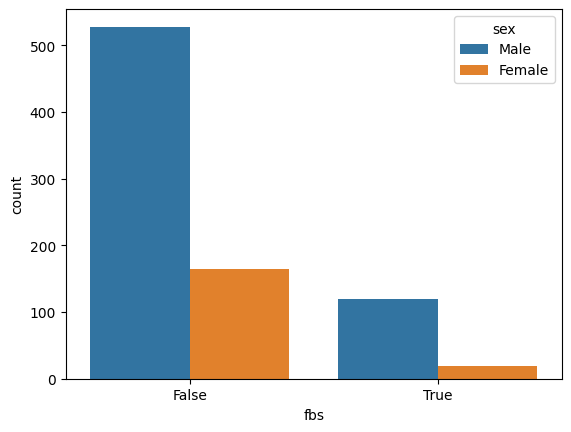

In [33]:
sns.countplot(x='fbs', hue='sex', data=df);

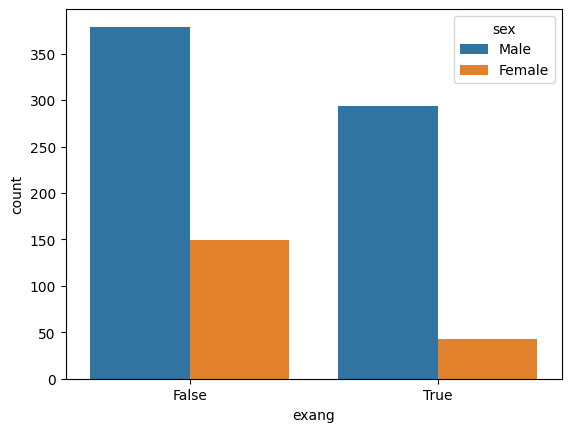

In [36]:
sns.countplot(x='exang', hue='sex', data=df);

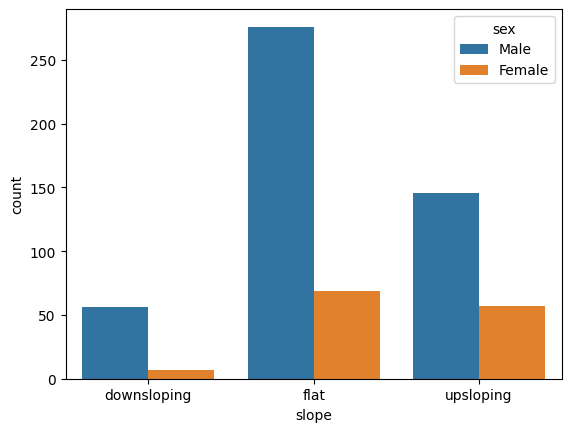

In [49]:
sns.countplot(x='slope', hue='sex', data=df);

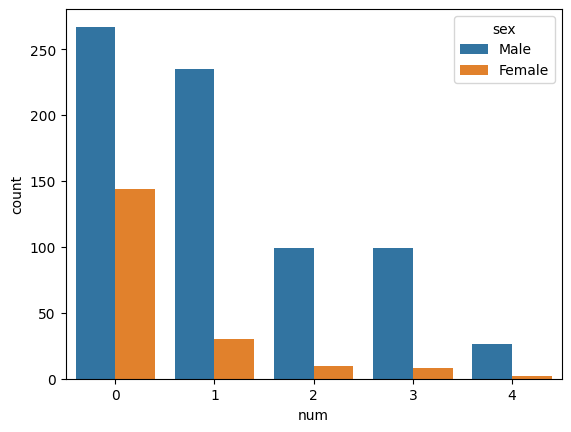

In [50]:
sns.countplot(x='num', hue='sex', data=df);

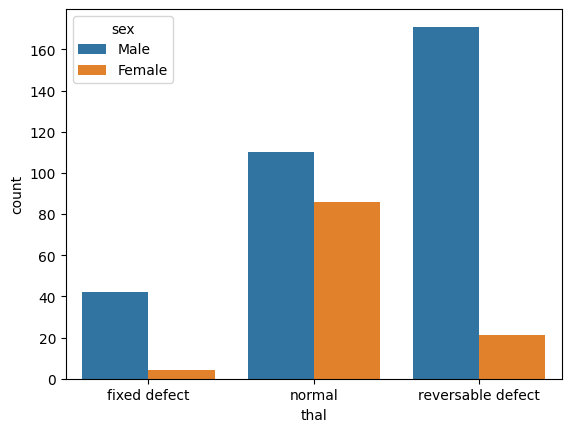

In [51]:
sns.countplot(x='thal', hue='sex', data=df);

In [58]:
df.corr(numeric_only=True)['num']

,num
age,0.339596
trestbps,0.122291
chol,-0.231547
thalch,-0.366265
oldpeak,0.443084
ca,0.516216
num,1.000000


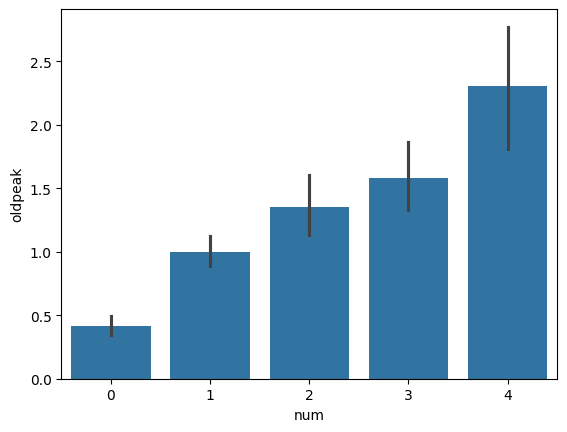

In [62]:
sns.barplot(x='num', y='oldpeak', data=df);

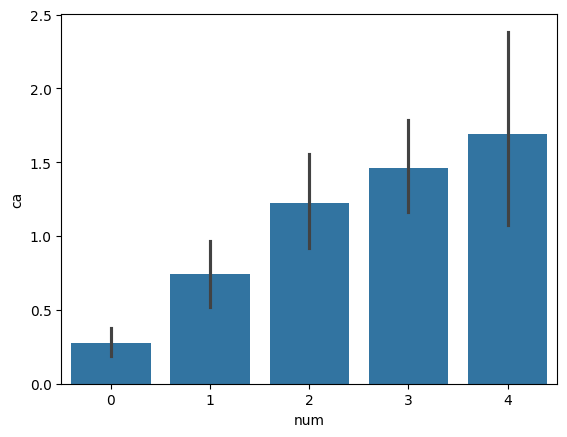

In [63]:
sns.barplot(x='num', y='ca', data=df);

In [64]:
num = df.select_dtypes(exclude='object')
objet = df.select_dtypes(include='object')

In [65]:
dumies = pd.get_dummies(objet, drop_first=True)

In [66]:
df_final = pd.concat([dumies, num], axis=1)

In [67]:
df_final.head()

,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,...,slope_upsloping,thal_normal,thal_reversable defect,age,trestbps,chol,thalch,oldpeak,ca,num
0,True,False,False,False,False,False,True,True,False,False,...,False,False,False,63,145.0,233.0,150.0,2.3,0.0,0
1,True,False,False,False,False,False,False,False,False,False,...,False,True,False,67,160.0,286.0,108.0,1.5,3.0,2
2,True,False,False,False,False,False,False,False,False,False,...,False,False,True,67,120.0,229.0,129.0,2.6,2.0,1
3,True,False,False,False,False,True,False,False,True,False,...,False,True,False,37,130.0,250.0,187.0,3.5,0.0,0
4,False,False,False,False,True,False,False,False,False,False,...,True,True,False,41,130.0,204.0,172.0,1.4,0.0,0


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X = df_final.drop('num', axis=1)
y = df_final['num']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = StandardScaler()

In [73]:
scale_X_train = scaler.fit_transform(X_train)
scale_X_test = scaler.transform(X_test)

In [75]:
from xgboost import XGBClassifier

In [76]:
model = XGBClassifier()

In [77]:
model.fit(scale_X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
pd.DataFrame(model.feature_importances_, index=X.columns, columns=['Importance']).sort_values('Importance', ascending=False).head(10)

,Importance
dataset_Hungary,0.197651
exang_True,0.152004
cp_atypical angina,0.068944
sex_Male,0.064922
dataset_Switzerland,0.063363
ca,0.048528
thal_normal,0.045882
cp_non-anginal,0.038201
oldpeak,0.035392
dataset_VA Long Beach,0.029032


In [81]:
import shap

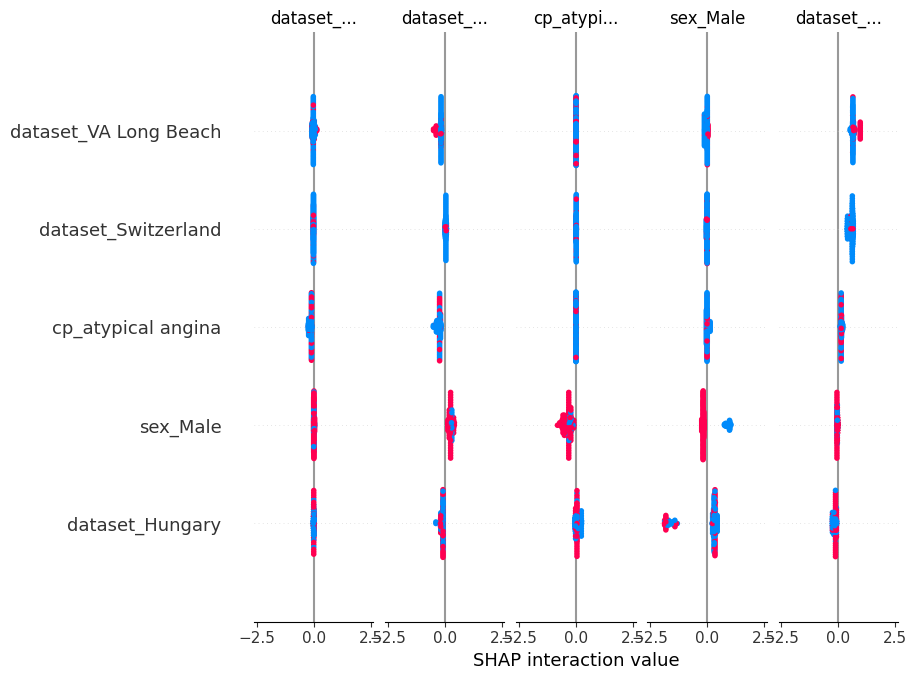

In [85]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)